In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from core.data import CompressionMetrics
from core.utils import make_dual_update, round_sig
from core.video import compress_video, reconstruct_video

In [3]:
video_raw = iio.imread("../sources/drosophila_1slice.y4m").astype(np.float32)
video_raw = video_raw[:, :, :, 0]
nx, ny = 100, 100
video = video_raw[:, :nx, :ny]

# To view the first frame
# plt.imshow(video[0], cmap="gray")
# plt.show()

In [4]:
# Hyperparameters
lp_degree = 2.0
block_size = 10
cutoff = None
poly_degrees = np.arange(2, 12, 1) - 1
t_degree = 20

In [5]:
metrics_list = []
video_rec_list = []
for poly_degree in poly_degrees:
    c_t, X_design, t_design_matrix, rescale = compress_video(
        video=video,
        poly_degree=poly_degree,
        t_degree=t_degree,
        block_size=block_size,
        lp_degree=lp_degree,
        lasso=False,
        cutoff=cutoff
    )
    
    c_t = round_sig(c_t)
    video_rec = reconstruct_video(video, block_size, c_t, X_design, t_design_matrix, rescale)
    metrics_list.append(CompressionMetrics(video, video_rec, c_t))
    video_rec_list.append(video_rec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    2.0s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s


[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s


[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s


[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    0.2s finished


In [6]:
# Extract values
psnr_values = [m.psnr for m in metrics_list]
space_saved_values = [m.space_saved for m in metrics_list]

## Plotting PSNR (dB) and Space Saved vs Polynomial Degree

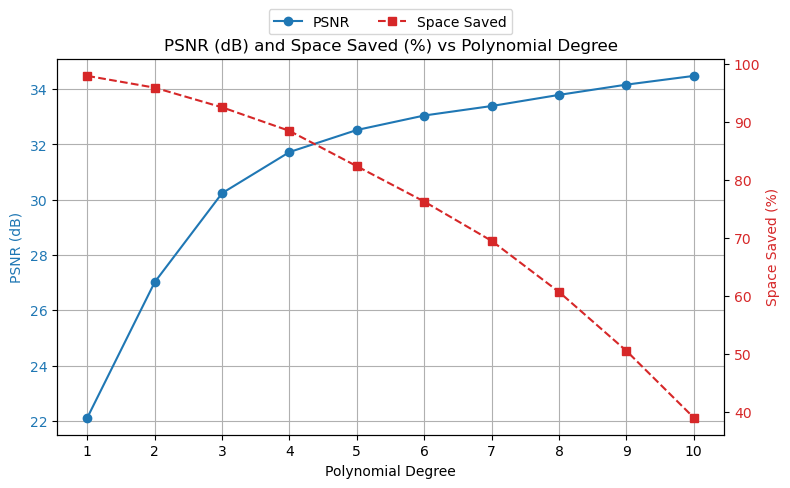

In [7]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot PSNR on primary y-axis
ln1 = ax1.plot(poly_degrees, psnr_values, marker="o", linestyle="-", color="tab:blue", label="PSNR")
ax1.set_xlabel("Polynomial Degree")
ax1.set_ylabel("PSNR (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)
ax1.set_xticks(poly_degrees)

# Plot space saved on secondary y-axis
ax2 = ax1.twinx()
ln2 = ax2.plot(poly_degrees, space_saved_values, marker="s", linestyle="--", color="tab:red", label="Space Saved")
ax2.set_ylabel("Space Saved (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends and place outside top-left
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title("PSNR (dB) and Space Saved (%) vs Polynomial Degree")
plt.tight_layout()

plt.savefig("../results/video/drosophila_1slice/plots/psnr__bs=%s__cutoff=%s__lp=%s__poly_degs=%s-%s__t_degree=%s__dtype=%s.png" %
(block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[-1], t_degree, c_t.dtype))

plt.show()

## Plotting Space Saved (%) vs PSNR (dB)

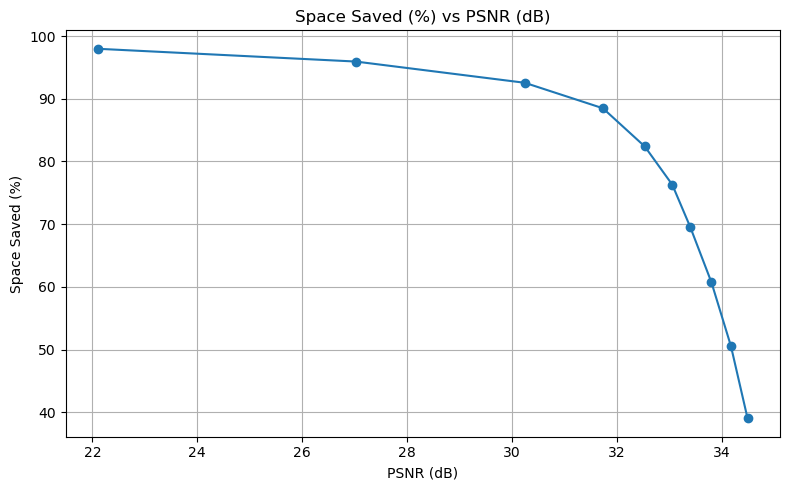

In [8]:
# Create figure and primary axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot PSNR vs space saved
ax.plot(psnr_values, space_saved_values, marker="o", linestyle="-")
ax.set_xlabel("PSNR (dB)")
ax.set_ylabel("Space Saved (%)")
ax.grid(True)

plt.title("Space Saved (%) vs PSNR (dB)")
plt.tight_layout()

plt.savefig("../results/video/drosophila_1slice/plots/space__vs__psnr____bs=%s__cutoff=%s__lp=%s__poly_degs=%s-%s__t_degree=%s__dtype=%s.png" %
(block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[-1], t_degree, c_t.dtype))

plt.show()

## Here we check video quality, and compare to produced metrics

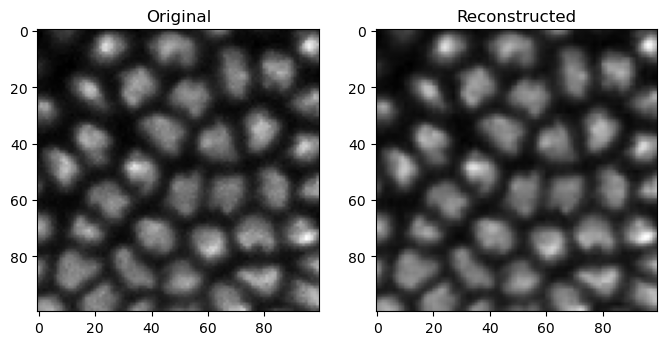

In [9]:
# To view a video: calling make_update function defined in utils.py - next cell plays the video
fig, ax = plt.subplots(1, 2, figsize=(8,4))

im_orig = ax[0].imshow(video[0], cmap='gray')
ax[0].set_title("Original")

# Choose which reconstruction of the video you wish to see
idx_rec = 5
im_rec = ax[1].imshow(video_rec_list[idx_rec][0], cmap='gray')
ax[1].set_title("Reconstructed")

update = make_dual_update(video, video_rec_list[idx_rec], im_orig, im_rec)
ani = animation.FuncAnimation(fig, update, frames=len(video), interval=200, blit=True)

In [10]:
from IPython.display import HTML
HTML(ani.to_jshtml())